# Unsupervised Learning Dimensionality Reduction

## 1. Answers

The most affected model is KNN, because it relies on the distance between objects which is highly screwed in the curse of dimensionality scenario. Linear models without reguralization and Decision Trees can also be affected by it though in the lesser form.

PCA and SVD are different ways to approximate matrices. The PCA reduces dimensionality of the matrix by trying to preserve as much variance as possible. It is more of a statistical method, which for example can be used to reduce the number of features in a matrix. SVD on the other hand is a method from linear algebra, which is used to factorize the matrix into 3, which gives the optimal low-rank approximation.

NMF is an matrix factorization algorithm wich factorizes the matrix in 2. Compared to SVD it gives more interpretive results with features which can be combined additively. Though on the contrary this algorithm can only be applied to non-negative data, and the approximations it gives are often not optimal due to the iterative nature of the algorithm.

LLE is a dimensionality reduction algorithm, main advantages of which are that it is non-linear, it preserves local structure of data and it doesn't get stuck on the local minimum. The main steps of the algorithm are: finding k local neibourghs, building a weight matrix which best reconstructs the original, find the resulting low-dimensional matrix.

## 2.Classification with Sparse Features

In [ ]:
import os
import umap
import struct
import pandas as pd
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt

from PIL import Image
from scipy.linalg import svd
from cv2 import VideoCapture, cvtColor, COLOR_BGR2GRAY

from sklearn.linear_model import ElasticNet
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, silhouette_score
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.datasets import fetch_openml
from sklearn.manifold import TSNE, LocallyLinearEmbedding

In [ ]:
users = pd.read_csv("data/Users.csv")
books = pd.read_csv("data/Books.csv")
ratings = pd.read_csv("data/Ratings.csv")

/tmp/ipython-input-954827608.py:2: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  books = pd.read_csv("/content/drive/MyDrive/21 school/Books.csv")


In [ ]:
rated_isbns = ratings['ISBN'].unique()
isbn_to_idx = {isbn: idx for idx, isbn in enumerate(rated_isbns)}

row_indices = ratings['User-ID'].values - 1
col_indices = ratings['ISBN'].map(isbn_to_idx)
ratings_values = ratings['Book-Rating'].values + 1

sparse_matrix = sp.coo_matrix((ratings_values, (row_indices, col_indices)), shape=(len(users["User-ID"]), len(rated_isbns)))

In [ ]:
target = users["Age"]
target = target.fillna(target.mean())
scaler = StandardScaler(with_mean=False)
data = pd.DataFrame.sparse.from_spmatrix(scaler.fit_transform(sparse_matrix))

In [ ]:
data.shape

(278858, 340556)

In [ ]:
train, valid = int(data.shape[0] * 0.25), int(data.shape[0] * 0.5)
data_train, target_train = data.loc[:train], target.loc[:train]
data_val, target_val = data.loc[train:valid], target.loc[train:valid]
data_test, target_test = data.loc[valid:], target.loc[valid:]

In [ ]:
%%time
elas_net = ElasticNet(random_state=21)
elas_net.fit(data_train, target_train)

CPU times: user 1h 54min 14s, sys: 4.96 s, total: 1h 54min 19s
Wall time: 1h 56min 26s


ElasticNet(random_state=21)

In [ ]:
pred = elas_net.predict(data_val)
print(f"MSE : {mean_squared_error(target_val, pred)} \tR2 : {r2_score(target_val, pred)}")

MSE : 124.85109980877303 	R2 : -0.0001024999972110141


In [ ]:
%%time
hist_boost = GradientBoostingRegressor(random_state=21)
hist_boost.fit(data_train, target_train)

CPU times: user 19min 23s, sys: 548 ms, total: 19min 23s
Wall time: 19min 34s


GradientBoostingRegressor(random_state=21)

In [ ]:
pred = hist_boost.predict(data_val)
print(f"MSE : {mean_squared_error(target_val, pred)} \tR2 : {r2_score(target_val, pred)}")

MSE : 125.3250086163568 	R2 : -0.0038986810798058436


In [ ]:
reducer = umap.UMAP(n_components=10, random_state=21)
data_train_ured, data_val_ured = reducer.fit_transform(data_train), reducer.fit_transform(data_val)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [ ]:
pca_reducer = PCA(n_components=10, random_state=21)
data_train_pred, data_val_pred = reducer.fit_transform(data_train), reducer.fit_transform(data_val)

In [ ]:
%%time
elas_net = ElasticNet(random_state=21)
elas_net.fit(data_train_ured, target_train)
pred = elas_net.predict(data_val_ured)
print(f"MSE : {mean_squared_error(target_val, pred)} \tR2 : {r2_score(target_val, pred)}")

MSE : 124.83899918185048 	R2 : -5.569595674215222e-06
CPU times: user 55.6 ms, sys: 0 ns, total: 55.6 ms
Wall time: 44.2 ms


In [ ]:
%%time
hist_boost = GradientBoostingRegressor(random_state=21)
hist_boost.fit(data_train_ured, target_train)
pred = hist_boost.predict(data_val_ured)
print(f"MSE : {mean_squared_error(target_val, pred)} \tR2 : {r2_score(target_val, pred)}")

MSE : 432.66977134819297 	R2 : -2.4658414756562963
CPU times: user 53.3 s, sys: 35.7 ms, total: 53.4 s
Wall time: 53.8 s


In [ ]:
%%time
elas_net = ElasticNet(random_state=21)
elas_net.fit(data_train_pred, target_train)
pred = elas_net.predict(data_val_pred)
print(f"MSE : {mean_squared_error(target_val, pred)} \tR2 : {r2_score(target_val, pred)}")

MSE : 124.83899918185048 	R2 : -5.569595674215222e-06
CPU times: user 35.1 ms, sys: 1.98 ms, total: 37.1 ms
Wall time: 43.1 ms


In [ ]:
%%time
hist_boost = GradientBoostingRegressor(random_state=21)
hist_boost.fit(data_train_pred, target_train)
pred = hist_boost.predict(data_val_pred)
print(f"MSE : {mean_squared_error(target_val, pred)} \tR2 : {r2_score(target_val, pred)}")

MSE : 432.66977134819297 	R2 : -2.4658414756562963
CPU times: user 55 s, sys: 19.9 ms, total: 55 s
Wall time: 55.6 s


## 3.Visualizations

In [ ]:
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
data, target = mnist.data, mnist.target
target = target.astype(int)

In [ ]:
pca = PCA(n_components=2)
data_pca = pca.fit_transform(data)
print(f"Silhouette score : {silhouette_score(data_pca, target)}")

Silhouette score : 0.022644916021761212


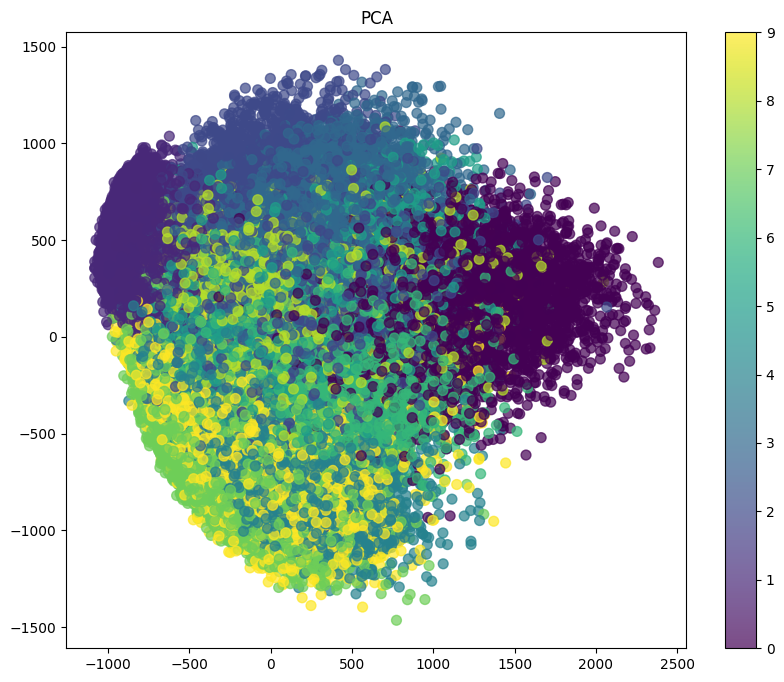

In [ ]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(data_pca[:, 0], data_pca[:, 1], c=target, s=50, alpha=0.7)
plt.title('PCA')
plt.colorbar(scatter)
plt.show()

In [ ]:
svd = TruncatedSVD(n_components=2, algorithm='arpack')
data_svd = svd.fit_transform(data)
print(f"Silhouette score : {silhouette_score(data_svd, target)}")

Silhouette score : -0.02943505198442469


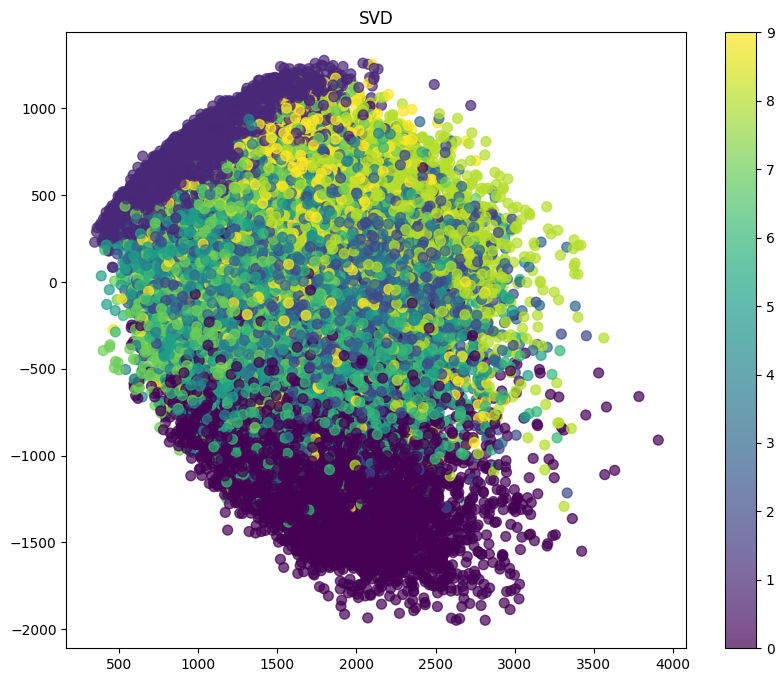

In [ ]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(data_svd[:, 0], data_svd[:, 1], c=target, s=50, alpha=0.7)
plt.title('SVD')
plt.colorbar(scatter)
plt.show()

In [ ]:
tsne = TSNE(n_components=2)
data_tsne = tsne.fit_transform(data)
print(f"Silhouette score : {silhouette_score(data_tsne, target)}")

Silhouette score : 0.37671151757240295


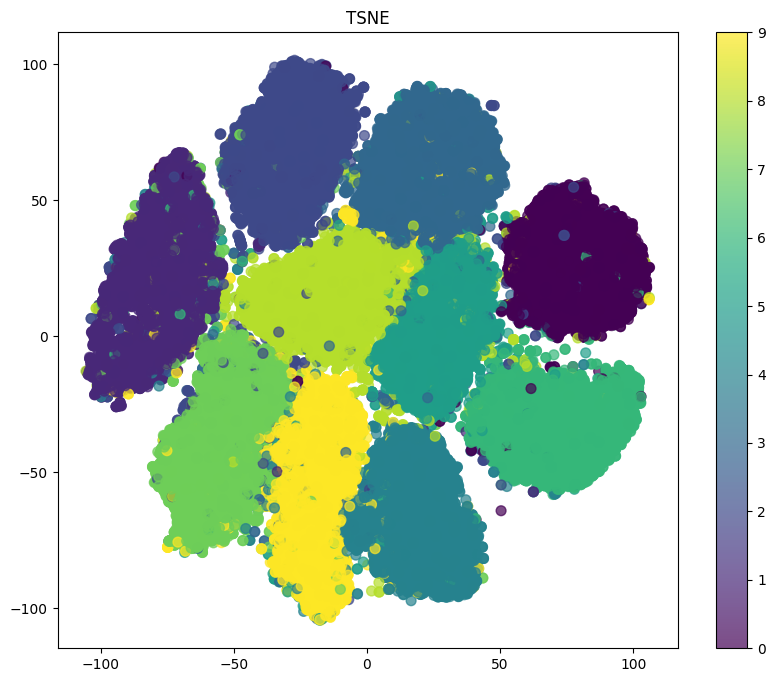

In [ ]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(data_tsne[:, 0], data_tsne[:, 1], c=target, s=50, alpha=0.7)
plt.title('TSNE')
plt.colorbar(scatter)
plt.show()

In [ ]:
umap = umap.UMAP(n_components=2, random_state=21)
data_umap = umap.fit_transform(data)
print(f"Silhouette score : {silhouette_score(data_umap, target)}")

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Silhouette score : 0.5338681936264038


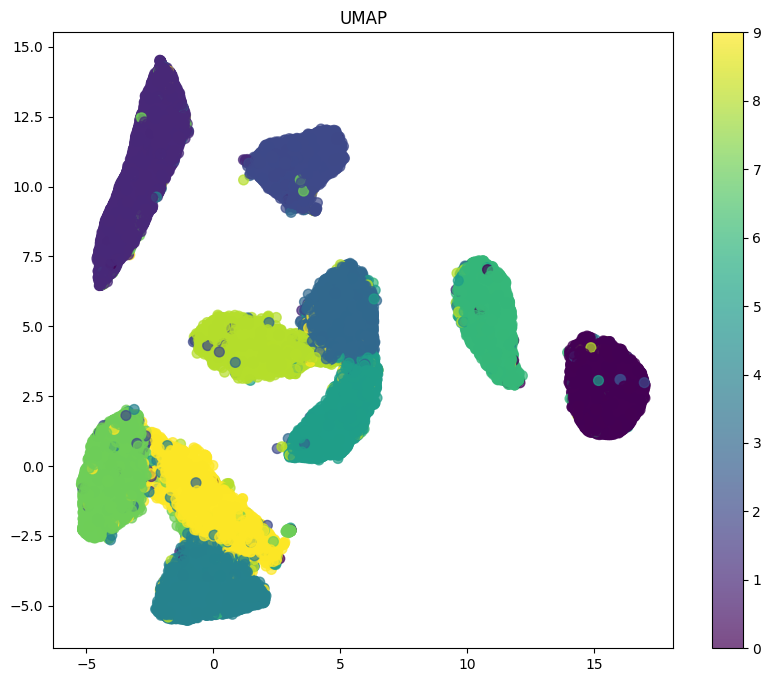

In [ ]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(data_umap[:, 0], data_umap[:, 1], c=target, s=50, alpha=0.7)
plt.title('UMAP')
plt.colorbar(scatter)
plt.show()

## 4.Image compression using SVD

In [ ]:
pics = []
for i in range(1, 4):
    pic = Image.open(f"data/pic_{i}.jpg").convert('L')
    pic = np.asarray(pic)
    pics.append(pic)

In [ ]:
def pic_plotting(pic):
    U, s, Vh = svd(pic)
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    axes = axes.ravel()

    for i, rank in enumerate([1, 5, 10, 25, 35, 50, 100, 250, 500, 780]):
        reconstructed = U[:, :rank] @ np.diag(s[:rank]) @ Vh[:rank, :]
        axes[i].imshow(reconstructed, cmap='gray')
        axes[i].set_title(f'Rank {rank}')
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

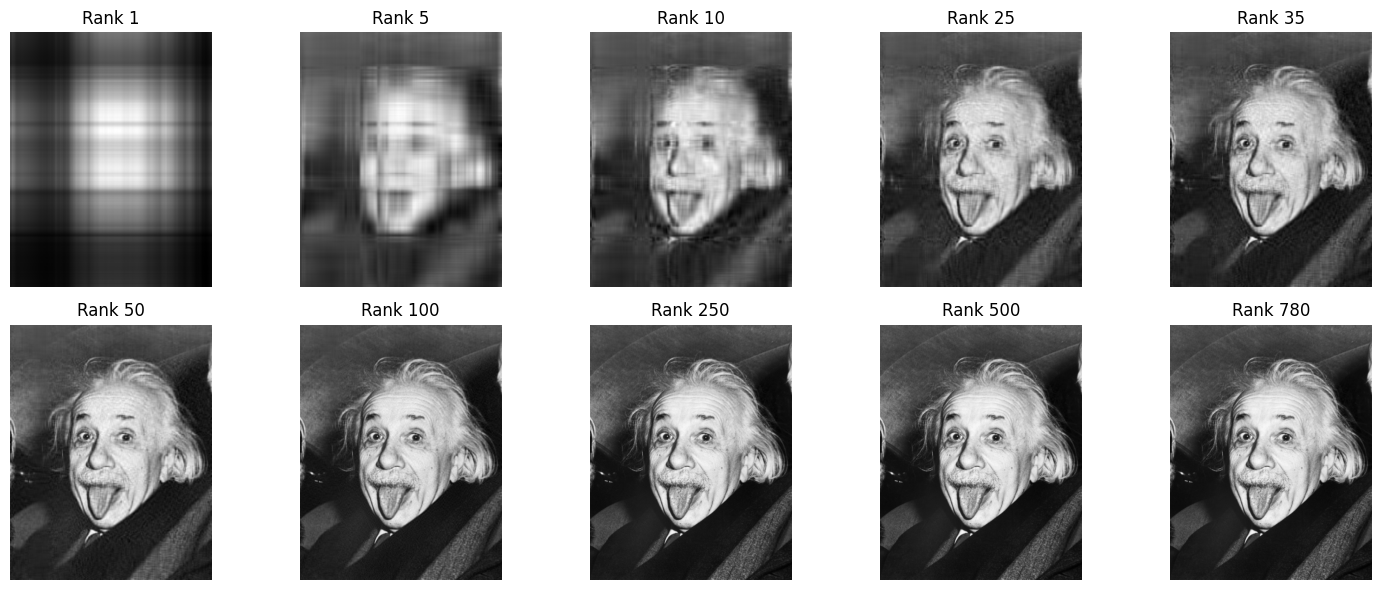

In [ ]:
pic_plotting(pics[0])

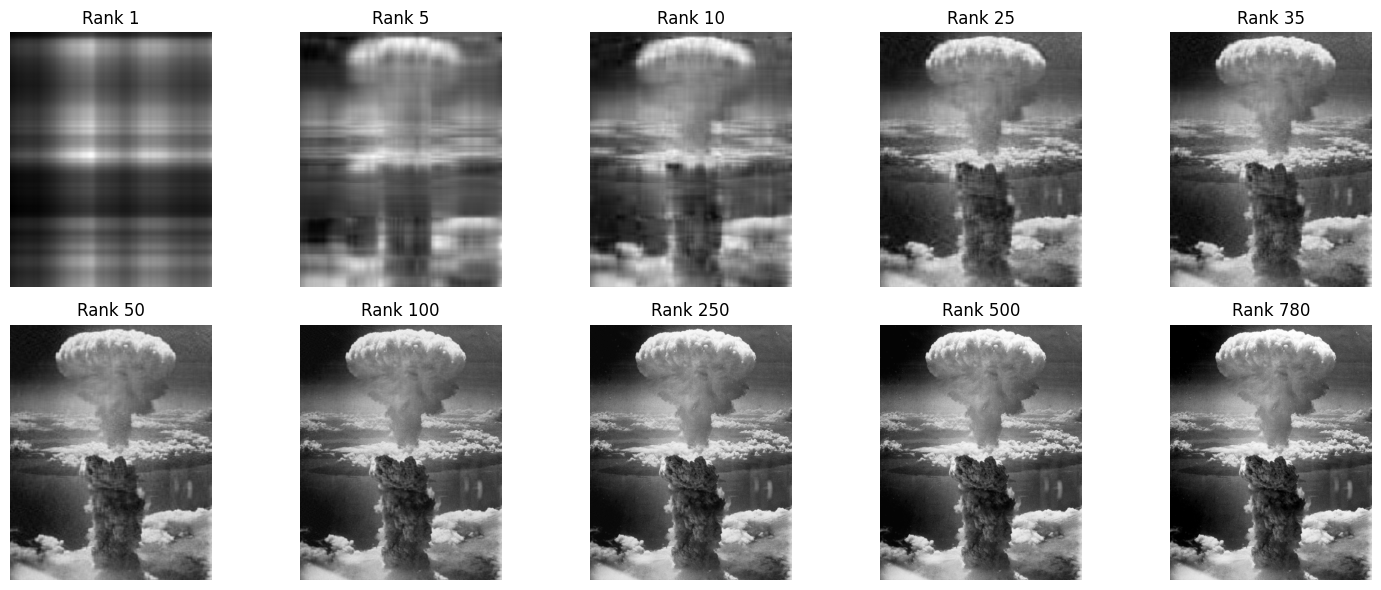

In [ ]:
pic_plotting(pics[1])

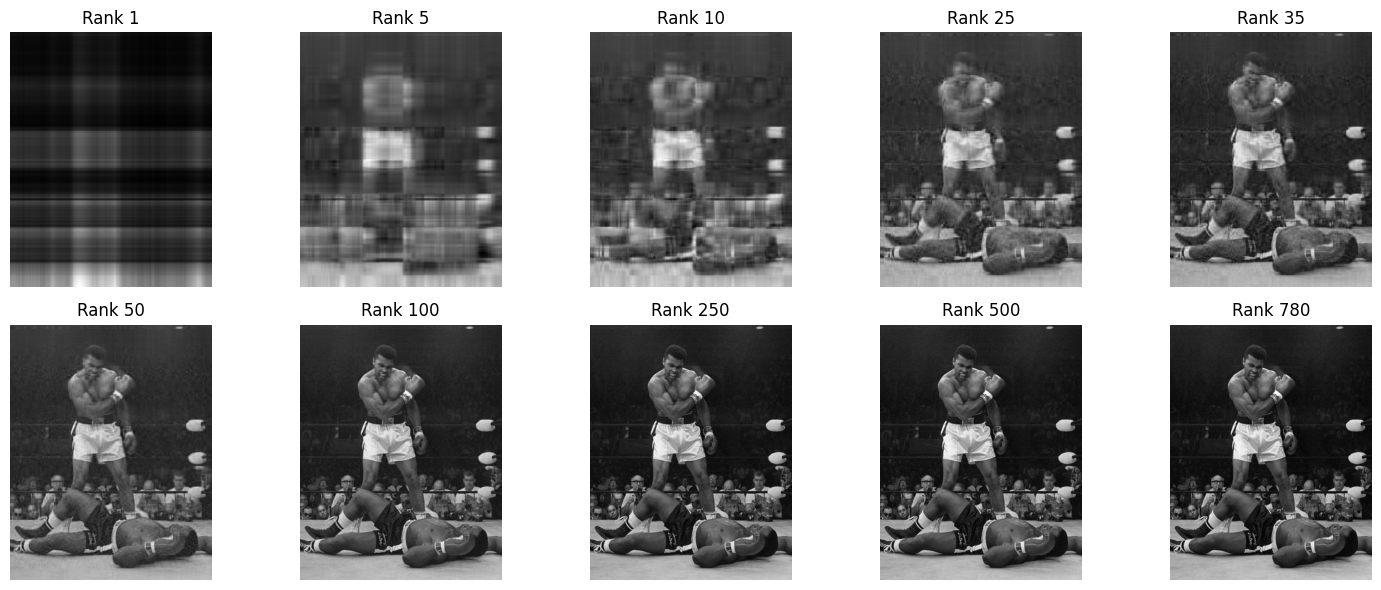

In [ ]:
pic_plotting(pics[2])

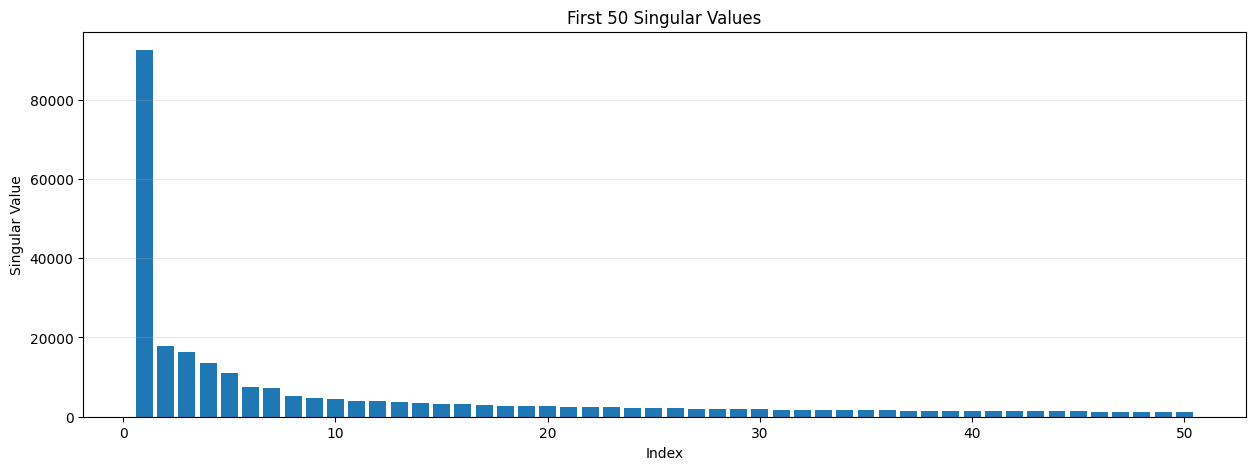

In [ ]:
U, s, Vh = svd(pics[0])
plt.figure(figsize=(15, 5))
plt.bar(range(1, 51), s[:50])
plt.xlabel('Index')
plt.ylabel('Singular Value')
plt.title('First 50 Singular Values')
plt.grid(True, alpha=0.3, axis='y')

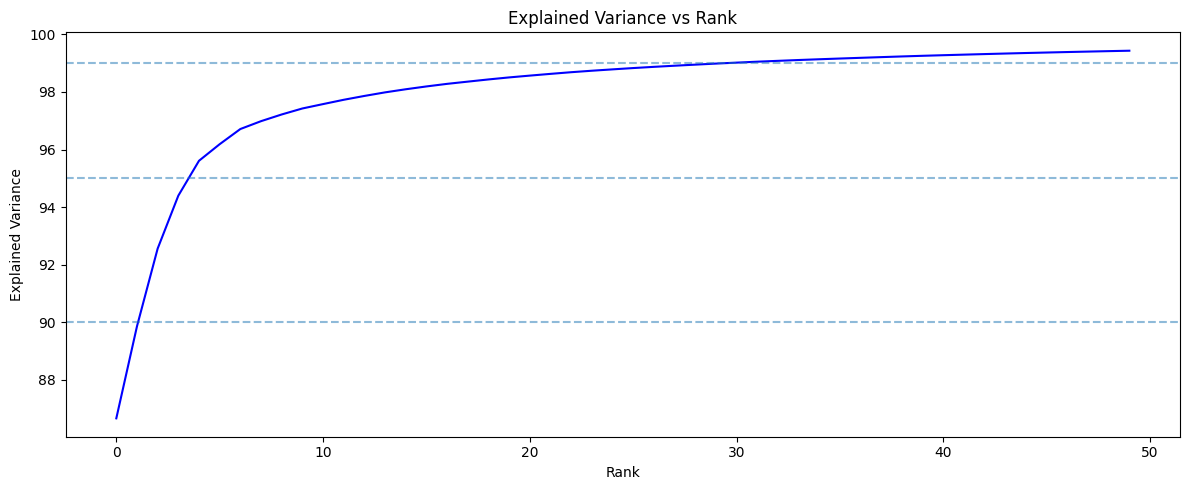

In [ ]:
cumulative_var = np.cumsum(s**2) / np.sum(s**2) * 100

plt.figure(figsize=(12, 5))
plt.plot(cumulative_var[:50], 'b-')
plt.xlabel('Rank')
plt.ylabel('Explained Variance')
plt.title('Explained Variance vs Rank')
plt.axhline(y=99, linestyle='--', alpha=0.5)
plt.axhline(y=95, linestyle='--', alpha=0.5)
plt.axhline(y=90, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Explained variance is a metric which measures the proportion of variance for which the rank accounts

## 5.Background detection using SVD

In [ ]:
vid = VideoCapture("data/Video_008.avi")
frames = []

while True:
    ret, frame = vid.read()
    if not ret:
        break
    frame = cvtColor(frame, COLOR_BGR2GRAY)
    frame = frame.reshape(1, frame.shape[0] * frame.shape[1])
    frames.append(frame)

vid.release()
frames = np.array(frames)
frames = frames.reshape(frames.shape[0], frames.shape[2])

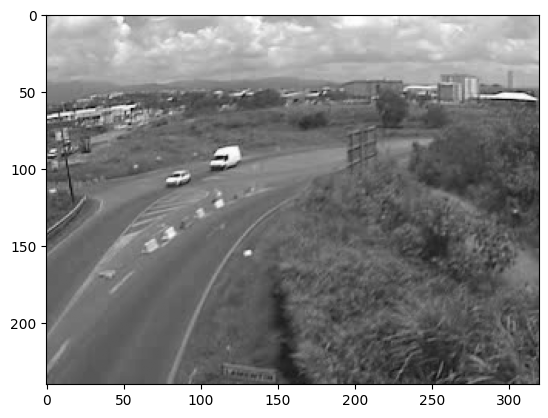

In [ ]:
plt.imshow(frames[0].reshape(240, 320), cmap="gray")

In [ ]:
U, S, Vt = svd(frames, full_matrices=False)

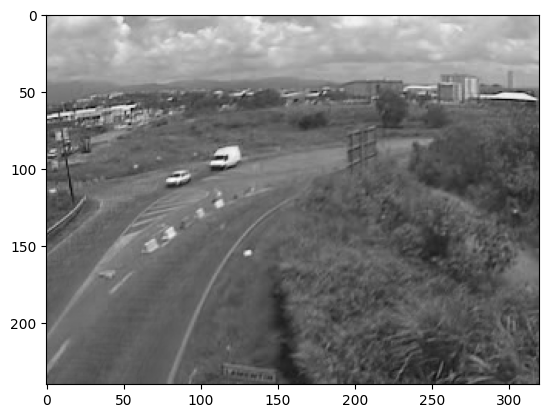

In [ ]:
rank = 300
rec = U[:, :rank] @ np.diag(S[:rank]) @ Vt[:rank, :]
plt.imshow(rec[0, :].reshape(240, 320), cmap="gray")

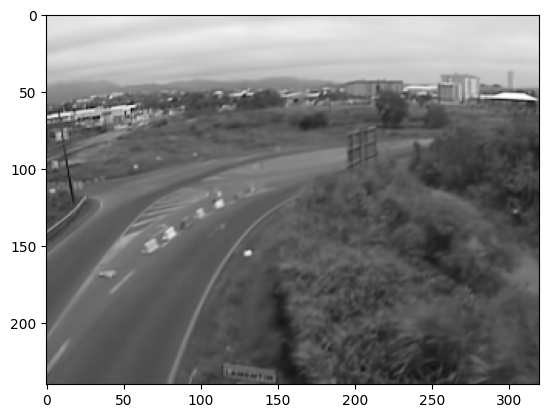

In [ ]:
rank = 1
rec = U[:, :rank] @ np.diag(S[:rank]) @ Vt[:rank, :]
plt.imshow(rec[0, :].reshape(240, 320), cmap="gray")

To get the background you can use the 1 rank

## 6.Bonus part

In [ ]:
def im_comipilation(emote):
    res = []
    files = os.listdir(f"data/{emote}")

    for f in files[:100]:
        im = Image.open(f"data/{emote}/{f}").convert('L')
        im = np.asarray(im)
        im = im.reshape(1, im.shape[0] * im.shape[1])
        res.append(im)

    return np.array(res)

In [ ]:
sad = im_comipilation("sad")
happy = im_comipilation("happy")
sad = sad.reshape(sad.shape[0], sad.shape[2])
happy = happy.reshape(happy.shape[0], happy.shape[2])

In [ ]:
emotes = np.vstack((sad, happy))
pca_emotes = PCA(n_components=150)
emotes_pca = pca_emotes.fit_transform(emotes)
avg_sad_pca = emotes_pca[:100].mean(axis=0)
avg_happy_pca = emotes_pca[100:].mean(axis=0)

In [ ]:
test_sad_pca = emotes_pca[7]
transformed_pca = test_sad_pca - avg_sad_pca * 5 + avg_happy_pca * 5

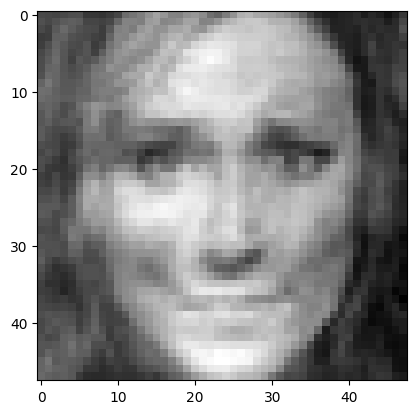

In [ ]:
plt.imshow(pca_emotes.inverse_transform(transformed_pca).reshape(48, 48), cmap="gray")

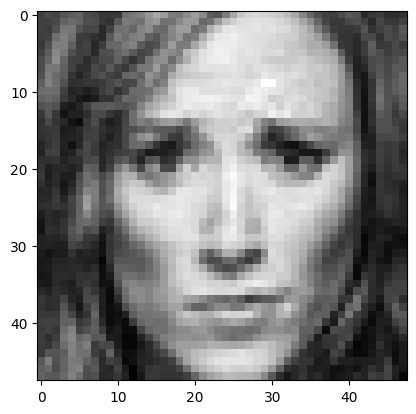

In [ ]:
plt.imshow(pca_emotes.inverse_transform(test_sad_pca).reshape(48, 48), cmap="gray")

In [ ]:
happy_coeff = 3
test_happy_pca = emotes_pca[156]
transformed_pca = test_happy_pca + happy_coeff * (avg_sad_pca - avg_happy_pca)

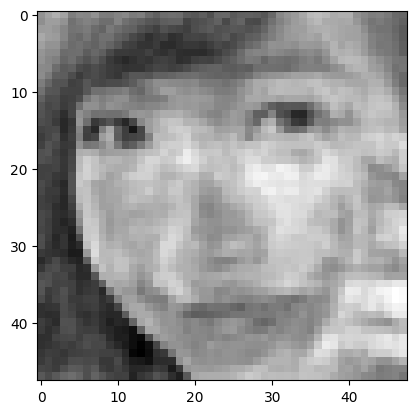

In [ ]:
plt.imshow(pca_emotes.inverse_transform(transformed_pca).reshape(48, 48), cmap="gray")

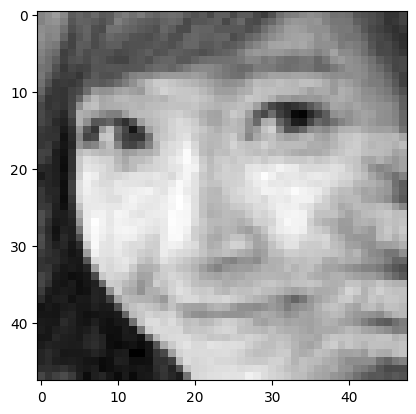

In [ ]:
plt.imshow(pca_emotes.inverse_transform(test_happy_pca).reshape(48, 48), cmap="gray")